In [ ]:
import pandas as pd
import numpy as np

## making a dataframe using lists

# l1 = ["Aryan","Himali","Soham"]
# l2 = [90,80,60]
# df = pd.DataFrame({'Name':l1,'Marks':l2})
# df

## making a dataframe using tuples

# 

# making a df using dictionary

data = {'Names':['Aryan','Himali','Sakshi'],
        'Marks':[90,80,80],
        'Age':[17,16,20]}

df =pd.DataFrame(data)

## df.describe
## df.shape

## df['Marks'].min()
## df['Marks'].max()
## df['Marks'].std()
## df['Marks'].var()
## df['Marks'].mean()
## df['Marks'].mode()
## df['Marks'].median()



0    80
Name: Marks, dtype: int64

In [30]:
import numpy as np

data = {'Names':['Aryan','Himali','Sakshi'],
        'Marks':[90,np.nan,80],
        'Age':[17,np.nan,np.nan]}

df = pd.DataFrame(data)
print("sum of null values is",df['Age'].isnull().sum())

df_cleaned = df.copy()
df_cleaned = df_cleaned.fillna(df_cleaned['Age'].mean())
# df_cleaned = df_cleaned.dropna(subset='Age')
df_cleaned


sum of null values is 2


,Names,Marks,Age
0,Aryan,90.0,17.0
1,Himali,17.0,17.0
2,Sakshi,80.0,17.0


In [41]:
import numpy as np
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

data = {
    'Name': ['Aarav', 'Rohan', 'Kunal', 'Vikram', 'Aarav', 'Neha', 'Suresh', 'Pooja', 'Anita', 'Rahul'],
    'Age': [25, 30, 35, 40, 25, 22, 30, 29, 30, 31],
    'Salary': [50000, 60000, 70000, 80000, 50000, 45000, 52000, 58000, 61000, 63000],
    'Score': [85, 90, 95, 90, 85, 88, 92, 89, 91, 87],
    'Height': [165, 170, 175, 180, 165, 160, 172, 168, 171, 173],
    'Weight': [60, 70, 80, 90, 60, 55, 75, 65, 72, 74]
}


# df = pd.DataFrame(data)
# std = StandardScaler()
# df_normalized = df.copy()
# df_normalized[['Salary','Score']] = std.fit_transform(df_normalized[['Salary','Score']])
# df_normalized


# bins = [0,30,70,100]
# labels = ['Young','Adult','Old']
# df_binned = df.copy()
# df_binned['Age Group']= pd.cut(df_binned['Age'],bins = bins,labels = labels)
# df_binned

pca = PCA(n_components=2)
cols=['Age','Salary','Score','Height','Age']
features =  df[cols]
pca_result = pca.fit_transform(features)
df_PCA = pd.DataFrame(data=pca_result,columns=['PCA1','PCA2'])
df_PCA



,PCA1,PCA2
0,-8900.004328,-2.489074
1,1100.000056,0.021791
2,11100.004440,2.532656
3,21100.007318,-1.675665
4,-8900.004328,-2.489074
5,-13900.007421,-1.761654
6,-6899.995730,8.151806
7,-900.001322,-1.022839
8,2100.000345,0.523508
9,4100.000970,-1.791455


In [45]:
h = df['Height']
w = df['Weight']
corr = np.corrcoef(h,w)[0][1]
print("value of correlation coefficient is",corr)

value of correlation coefficient is 0.989402894810298


In [56]:
corr = df[['Height','Weight']].corr(method= 'pearson')
corr

,Height,Weight
Height,1.000000,0.989403
Weight,0.989403,1.000000


In [ ]:
import numpy as np
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules

transactions = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter']
]

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
features = pd.DataFrame(data = te_array,columns=te.columns_)

apriori_result = apriori(features,min_support=0.4,use_colnames=True)
association_rules_result = association_rules(apriori_result,min_threshold=0.6,metric='confidence')

print("Result of apriori algorithm is: ", apriori_result)
print("Result after applying association_rules is ", association_rules_result)


Result of apriori algorithm is:     support         itemsets
0      0.8          (bread)
1      0.8         (butter)
2      0.6           (milk)
3      0.6  (butter, bread)
4      0.4    (milk, bread)
5      0.4   (milk, butter)
Result after applying association_rules is    antecedents consequents  antecedent support  consequent support  support  \
0    (butter)     (bread)                 0.8                 0.8      0.6   
1     (bread)    (butter)                 0.8                 0.8      0.6   
2      (milk)     (bread)                 0.6                 0.8      0.4   
3      (milk)    (butter)                 0.6                 0.8      0.4   

   confidence      lift  representativity  leverage  conviction  \
0    0.750000  0.937500               1.0     -0.04         0.8   
1    0.750000  0.937500               1.0     -0.04         0.8   
2    0.666667  0.833333               1.0     -0.08         0.6   
3    0.666667  0.833333               1.0     -0.08         0.6   



In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [5]:
# df.head()
# df.info
# df.shape
# df.describe

df['deposit'].value_counts()


deposit
no     5873
yes    5289
Name: count, dtype: int64

In [7]:
x = df.drop('deposit',axis = 1)
y = df['deposit']

In [11]:
le = LabelEncoder()
y = le.fit_transform(y)

x = pd.get_dummies(x)
y

array([1, 1, 1, ..., 0, 0, 0], shape=(11162,))

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=5,
    min_samples_split=10,
    criterion='gini',
    random_state=42
)
model.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
for depth in [3,5,7,9]:
    model = DecisionTreeClassifier(max_depth=depth,random_state=42)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print(accuracy_score(y_test,y_pred))

0.7693685624720108
0.7948947604120018
0.799373040752351
0.8069861173309449


In [22]:
accuracy = accuracy_score(y_pred,y_test)
print("accuracy is : ", accuracy*100 )

accuracy is :  80.6986117330945


In [25]:
print("confusion matrix: \n", confusion_matrix(y_pred,y_test))
print("classification_report: \n",classification_report(y_pred,y_test))

confusion matrix: 
 [[896 161]
 [270 906]]
classification_report: 
               precision    recall  f1-score   support

           0       0.77      0.85      0.81      1057
           1       0.85      0.77      0.81      1176

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



[Text(0.5108916938110749, 0.95, 'duration <= 205.5\ngini = 0.499\nsamples = 8929\nvalue = [4707, 4222]\nclass = no'),
 Text(0.2738701140065147, 0.85, 'poutcome_success <= 0.5\ngini = 0.322\nsamples = 3621\nvalue = [2890, 731]\nclass = no'),
 Text(0.39238090390879476, 0.8999999999999999, 'True  '),
 Text(0.19849348534201955, 0.75, 'month_mar <= 0.5\ngini = 0.266\nsamples = 3377\nvalue = [2843, 534]\nclass = no'),
 Text(0.13151465798045603, 0.65, 'duration <= 123.5\ngini = 0.245\nsamples = 3296\nvalue = [2826, 470]\nclass = no'),
 Text(0.0745114006514658, 0.55, 'month_oct <= 0.5\ngini = 0.107\nsamples = 1785\nvalue = [1684, 101]\nclass = no'),
 Text(0.04804560260586319, 0.45, 'month_feb <= 0.5\ngini = 0.096\nsamples = 1757\nvalue = [1668, 89]\nclass = no'),
 Text(0.026058631921824105, 0.35, 'month_apr <= 0.5\ngini = 0.074\nsamples = 1629\nvalue = [1566, 63]\nclass = no'),
 Text(0.013029315960912053, 0.25, 'month_sep <= 0.5\ngini = 0.054\nsamples = 1543\nvalue = [1500, 43]\nclass = no'),


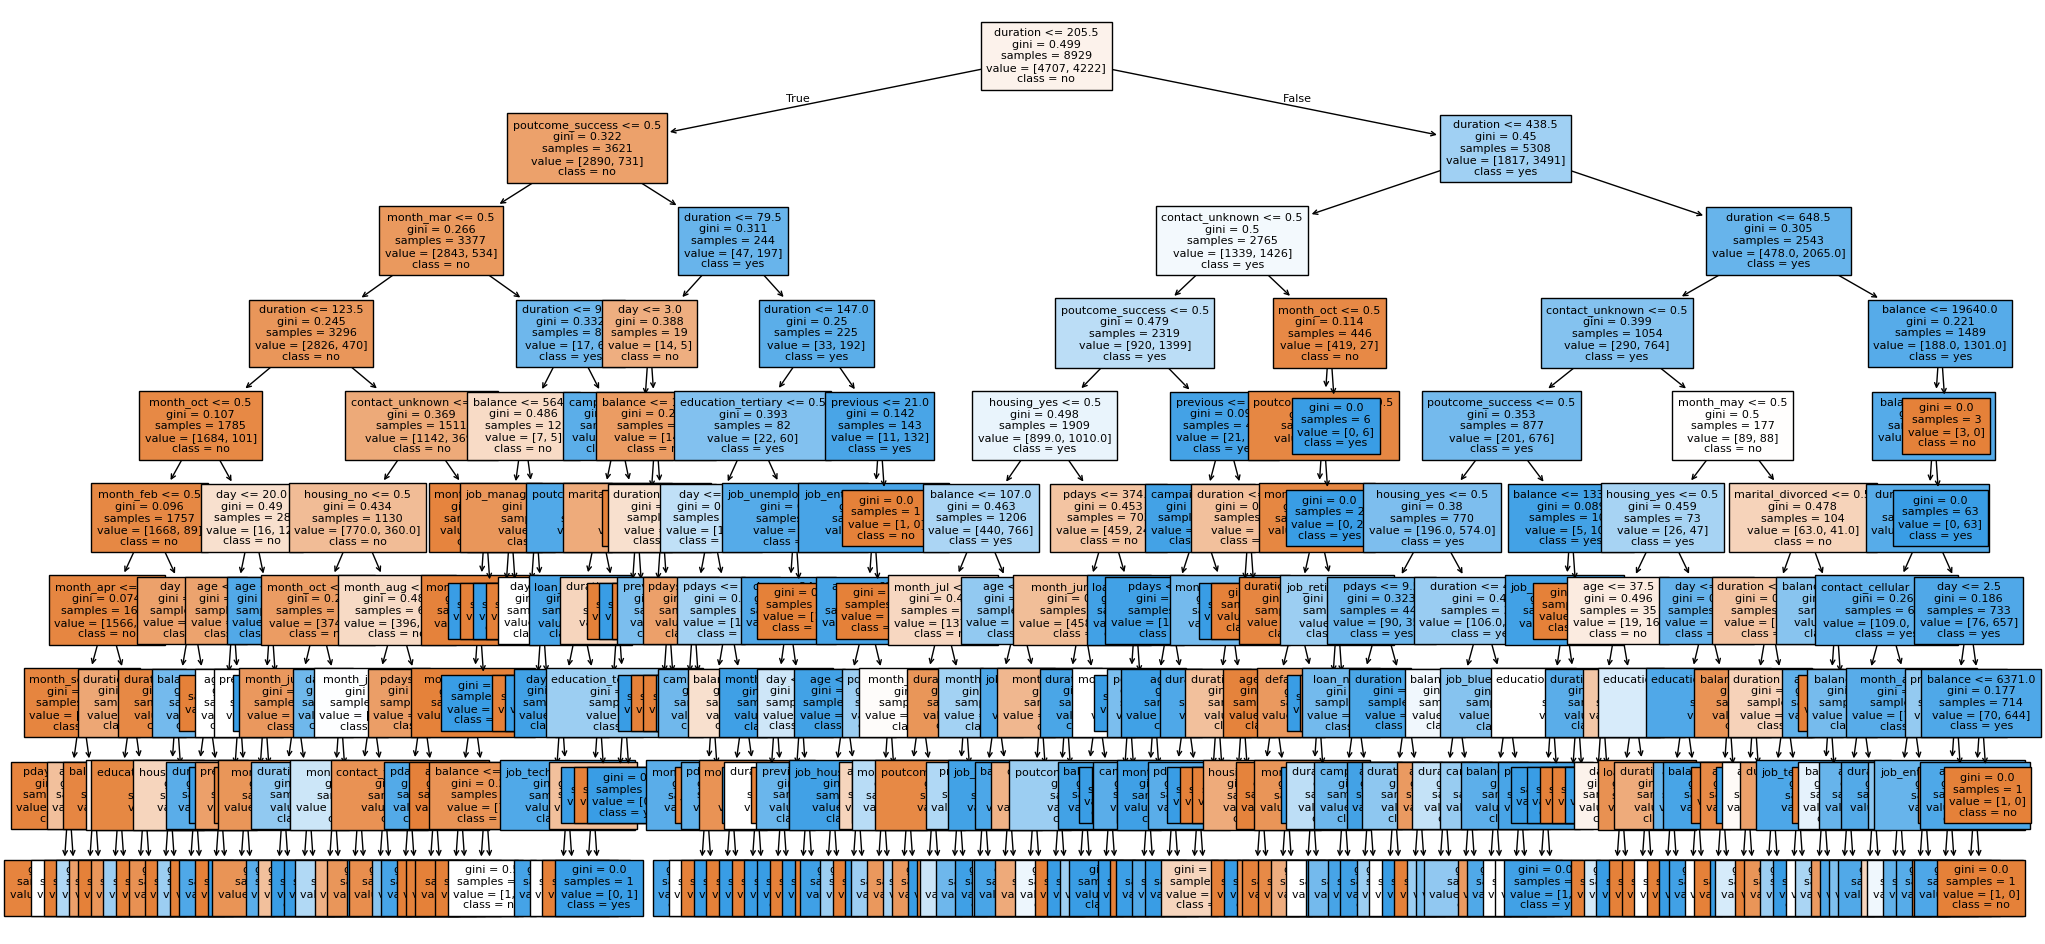

In [29]:
plt.figure(figsize=(25,12))

plot_tree(
    model,
    filled=True,
    feature_names=x.columns,
    class_names=["no","yes"],
    fontsize=8
)

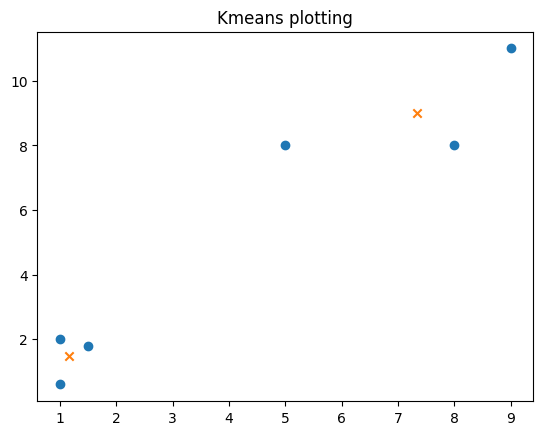

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11]
])

K = KMeans(n_clusters=2,random_state=42)
K.fit(X)

centroids = K.cluster_centers_
labels= K.labels_

plt.scatter(X[:,0],X[:,1],marker='o')
plt.scatter(centroids[:,0],centroids[:,1],marker='x')
plt.title("Kmeans plotting")